# 🖼️ Goruntu Isleme — MNIST Veri Seti ile Temelden Ileriye

Bu notebook, **MNIST el yazisi rakam veri seti** kullanarak goruntu isleminin temel kavramlarini adim adim ogretir.

---

## 📚 Icerik

| Bolum | Konu |
|-------|------|
| 0 | Kaggle API Kurulumu ve Veri Indirme |
| 1 | Kurulum ve Kutuphaneler |
| 2 | Goruntu Nedir? Piksel, Kanal, Boyut |
| 3 | Temel Goruntu Manipulasyonu |
| 4 | Renk Uzaylari (Grayscale) |
| 5 | Histogram Analizi |
| 6 | Goruntu Filtreleme (Bulaniklastirma, Keskinlestirme) |
| 7 | Kenar Tespiti (Edge Detection) |
| 8 | Morfolojik Islemler |
| 9 | Esikleme (Thresholding) |
| 10 | Kontur Tespiti |
| 11 | Ozellik Cikarimi ve Siniflandirma |

> **Veri Seti:** MNIST (Kaggle Digit Recognizer)
> - 42,000 egitim + 28,000 test goruntusu
> - 28x28 piksel, gri tonlamali (1 kanal)
> - 10 sinif (0-9 rakamlari)

### 📥 Veri Setini Indirme
Veri seti **Kaggle API** ile otomatik olarak indirilecektir. Sadece API bilgilerinizi girmeniz yeterli.

> **Nasil alinir?**
> 1. https://www.kaggle.com adresine gidin ve giris yapin
> 2. Sag ustteki profil resminize tiklayin -> "Settings"
> 3. "API" bolumunden "Create New Token" butonuna tiklayin
> 4. Indirilen `kaggle.json` dosyasindaki icerigi kullanin

## 🔧 Bolum 0 — Kaggle API Kurulumu ve Veri Indirme

Kaggle'dan veri setini otomatik indirmek icin API kimlik bilgilerinizi girin.

In [1]:
import getpass
import os
import json
import zipfile

# Kaggle API kimlik bilgilerini sor
print("=== Kaggle API Kimlik Bilgileri ===")
print("https://www.kaggle.com -> Settings -> API -> Create New Token")
print()

kullanici_adi = input("Kaggle kullanici adinizi girin: ")
api_key = getpass.getpass("Kaggle API key girin (gizli olarak girilecek): ")

# kaggle.json dosyasini olustur
kaggle_dir = os.path.expanduser('~/.kaggle')
os.makedirs(kaggle_dir, exist_ok=True)

kaggle_creds = {"username": kullanici_adi, "key": api_key}
with open(os.path.join(kaggle_dir, 'kaggle.json'), 'w') as f:
    json.dump(kaggle_creds, f)

print("\nKaggle API basariyla ayarlandi!")

=== Kaggle API Kimlik Bilgileri ===
https://www.kaggle.com -> Settings -> API -> Create New Token

Kaggle kullanici adinizi girin: https://www.kaggle.com/gamzedrn
Kaggle API key girin (gizli olarak girilecek): ··········

Kaggle API basariyla ayarlandi!


In [2]:
# kaggle kutuphanesini kur
!pip install kaggle -q

# MNIST Digit Recognizer veri setini indir
!kaggle competitions download -c digit-recognizer -p ./data/mnist --force

# Zip dosyasini cikar
zip_path = './data/mnist/digit-recognizer.zip'
if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('./data/mnist')
    print("MNIST veri seti basariyla indirildi!")
    print(f"Dosyalar: {os.listdir('./data/mnist')}")
else:
    print("Uyari: Zip dosyasi bulunamadi.")
    print("Veri seti sonraki hucrede sklearn ile otomatik indirilecek.")

401 Client Error: Unauthorized for url: https://api.kaggle.com/v1/competitions.CompetitionApiService/DownloadDataFiles
Uyari: Zip dosyasi bulunamadi.
Veri seti sonraki hucrede sklearn ile otomatik indirilecek.


## 🔧 Bolum 1 — Kurulum ve Kutuphaneler

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd

import cv2
from PIL import Image, ImageFilter, ImageEnhance

from scipy.ndimage import gaussian_filter, sobel, median_filter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.family'] = 'DejaVu Sans'

print("Tum kutuphaneler basariyla yuklendi!")

Tum kutuphaneler basariyla yuklendi!


### 📥 MNIST Veri Setini Yukle

In [4]:
# MNIST veri setini yukle
# Oncelikle Kaggle'dan indirilen CSV'yi dene, olmazsa sklearn ile yukle
csv_path = './data/mnist/train.csv'
csv_path2 = 'train.csv'

if os.path.exists(csv_path) or os.path.exists(csv_path2):
    path = csv_path if os.path.exists(csv_path) else csv_path2
    print(f"Kaggle CSV dosyasi bulundu: {path}")
    df = pd.read_csv(path)
    y = df['label'].values
    X = df.drop('label', axis=1).values
    X_images = X.reshape(-1, 28, 28).astype(np.uint8)
else:
    print("CSV dosyasi bulunamadi, sklearn ile indiriliyor...")
    from sklearn.datasets import fetch_openml
    mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
    X = mnist.data.astype(np.uint8)
    y = mnist.target.astype(int)
    X_images = X.reshape(-1, 28, 28)

print(f"Toplam goruntu sayisi: {X_images.shape[0]}")
print(f"Goruntu boyutu: {X_images.shape[1]}x{X_images.shape[2]} piksel")
print(f"Sinif sayisi: {len(np.unique(y))}")
print(f"Sinif dagilimi: {np.bincount(y)}")

CSV dosyasi bulunamadi, sklearn ile indiriliyor...
Toplam goruntu sayisi: 70000
Goruntu boyutu: 28x28 piksel
Sinif sayisi: 10
Sinif dagilimi: [6903 7877 6990 7141 6824 6313 6876 7293 6825 6958]


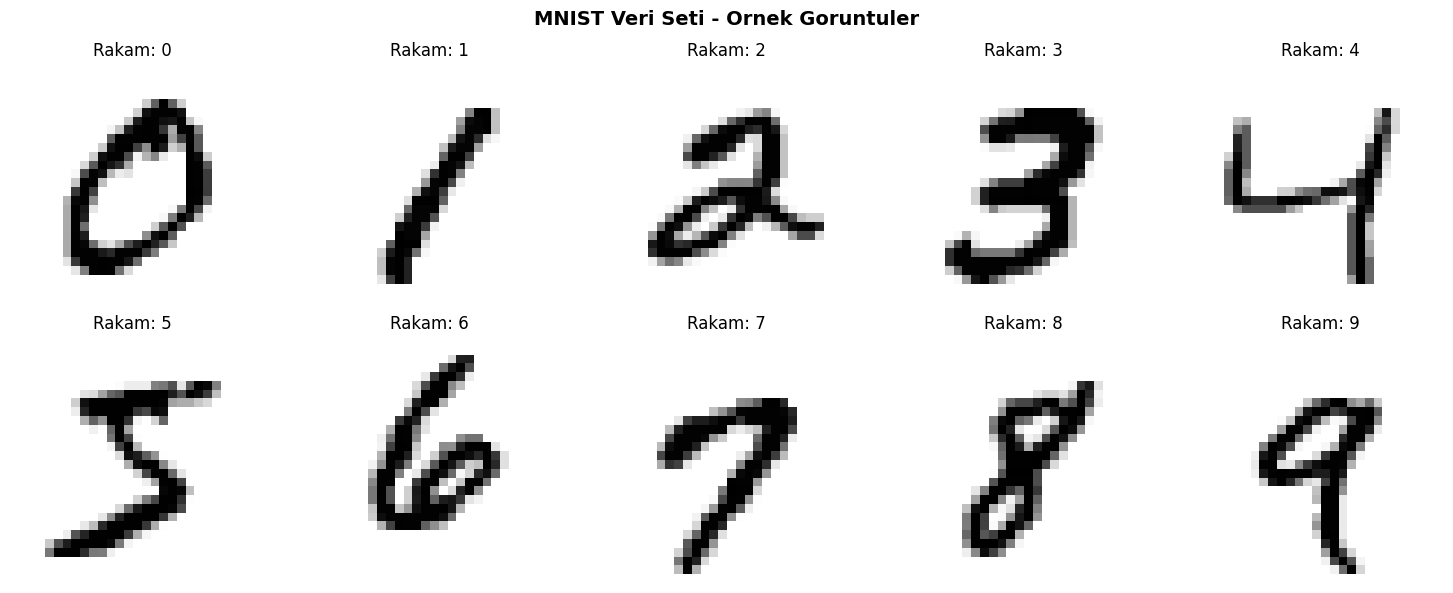

In [5]:
# Ornek goruntuleri gorsellestir
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
    idx = np.where(y == i)[0][0]
    ax.imshow(X_images[idx], cmap='gray_r')
    ax.set_title(f"Rakam: {i}", fontsize=12)
    ax.axis('off')

plt.suptitle("MNIST Veri Seti - Ornek Goruntuler", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 🔬 Bolum 2 — Goruntu Nedir? Piksel, Kanal, Boyut

- **Piksel**: Goruntunun en kucuk birimi. Her piksel 0-255 arasi bir sayidir.
- **Kanal**: Renk boyutu. RGB goruntude 3 kanal; gri goruntude 1 kanal.
- **Shape** `(H, W)`: Yukseklik x Genislik
- **dtype**: Veri tipi. `uint8` -> 0-255 tam sayi.

In [6]:
ornek = X_images[0]
H, W = ornek.shape

print("=== Goruntu Boyut Bilgisi ===")
print(f"Yukseklik (H): {H} piksel")
print(f"Genislik  (W): {W} piksel")
print(f"Kanal sayisi : 1  (Gri tonlama)")
print(f"Toplam piksel: {H * W:,}")
print(f"Veri tipi    : {ornek.dtype}")
print(f"Min deger    : {ornek.min()}")
print(f"Max deger    : {ornek.max()}")
print(f"Ortalama     : {ornek.mean():.1f}")

=== Goruntu Boyut Bilgisi ===
Yukseklik (H): 28 piksel
Genislik  (W): 28 piksel
Kanal sayisi : 1  (Gri tonlama)
Toplam piksel: 784
Veri tipi    : uint8
Min deger    : 0
Max deger    : 255
Ortalama     : 35.1


## ✂️ Bolum 3 — Temel Goruntu Manipulasyonu

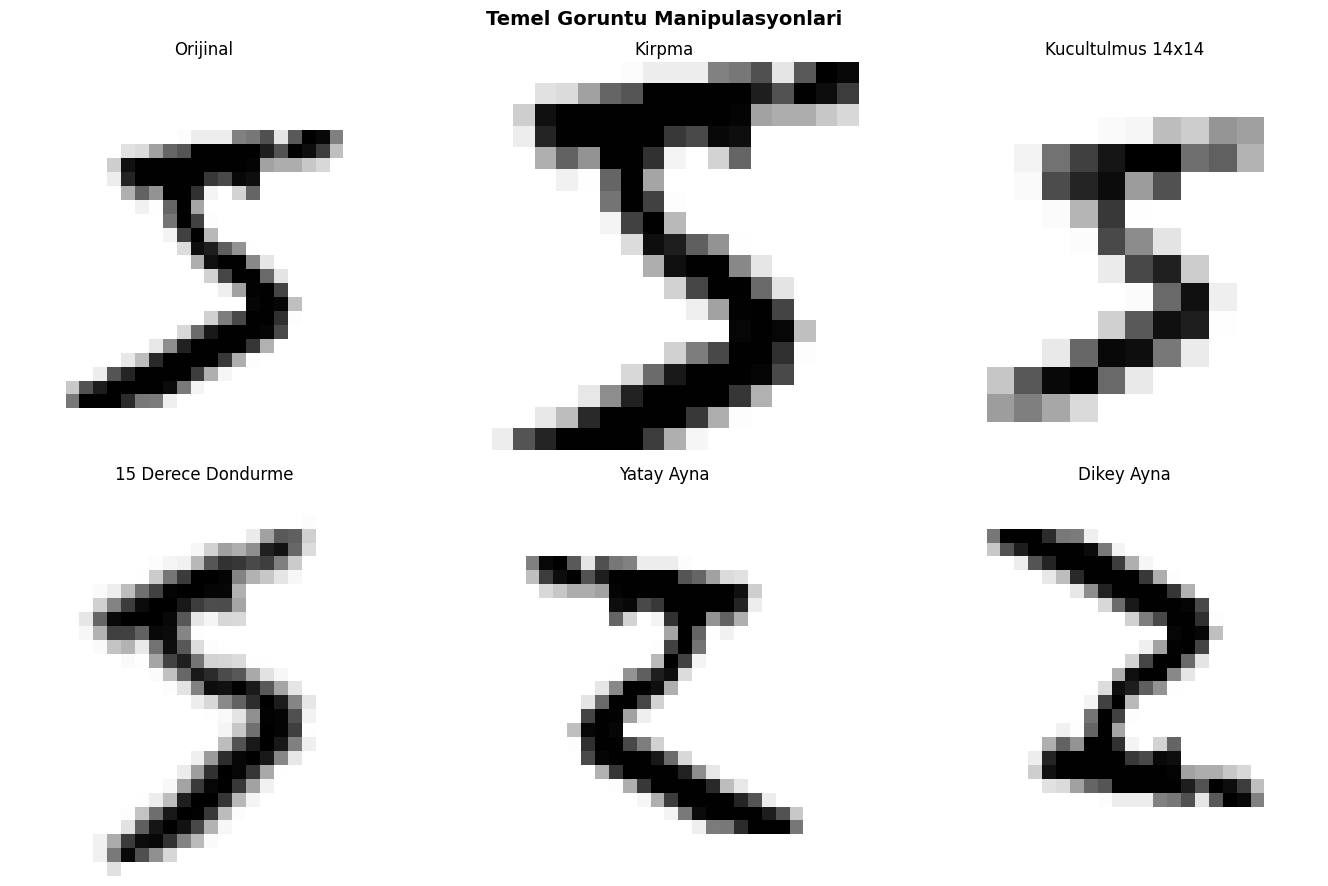

In [7]:
ornek = X_images[0].copy()

# Kirpma
crop = ornek[5:23, 5:23]
# Yeniden Boyutlandirma
img_small = cv2.resize(ornek, (14, 14))
img_large = cv2.resize(ornek, (56, 56))
# Dondurme
h, w = ornek.shape[:2]
M = cv2.getRotationMatrix2D((w//2, h//2), 15, 1.0)
img_rotated = cv2.warpAffine(ornek, M, (w, h))
# Yatay/Dikey Cevirme
img_flip_h = np.fliplr(ornek)
img_flip_v = np.flipud(ornek)

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes[0,0].imshow(ornek, cmap='gray_r');        axes[0,0].set_title("Orijinal")
axes[0,1].imshow(crop, cmap='gray_r');         axes[0,1].set_title("Kirpma")
axes[0,2].imshow(img_small, cmap='gray_r');    axes[0,2].set_title("Kucultulmus 14x14")
axes[1,0].imshow(img_rotated, cmap='gray_r');  axes[1,0].set_title("15 Derece Dondurme")
axes[1,1].imshow(img_flip_h, cmap='gray_r');   axes[1,1].set_title("Yatay Ayna")
axes[1,2].imshow(img_flip_v, cmap='gray_r');   axes[1,2].set_title("Dikey Ayna")
for ax in axes.flat: ax.axis('off')
plt.suptitle("Temel Goruntu Manipulasyonlari", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 🎨 Bolum 4 — Renk Uzaylari

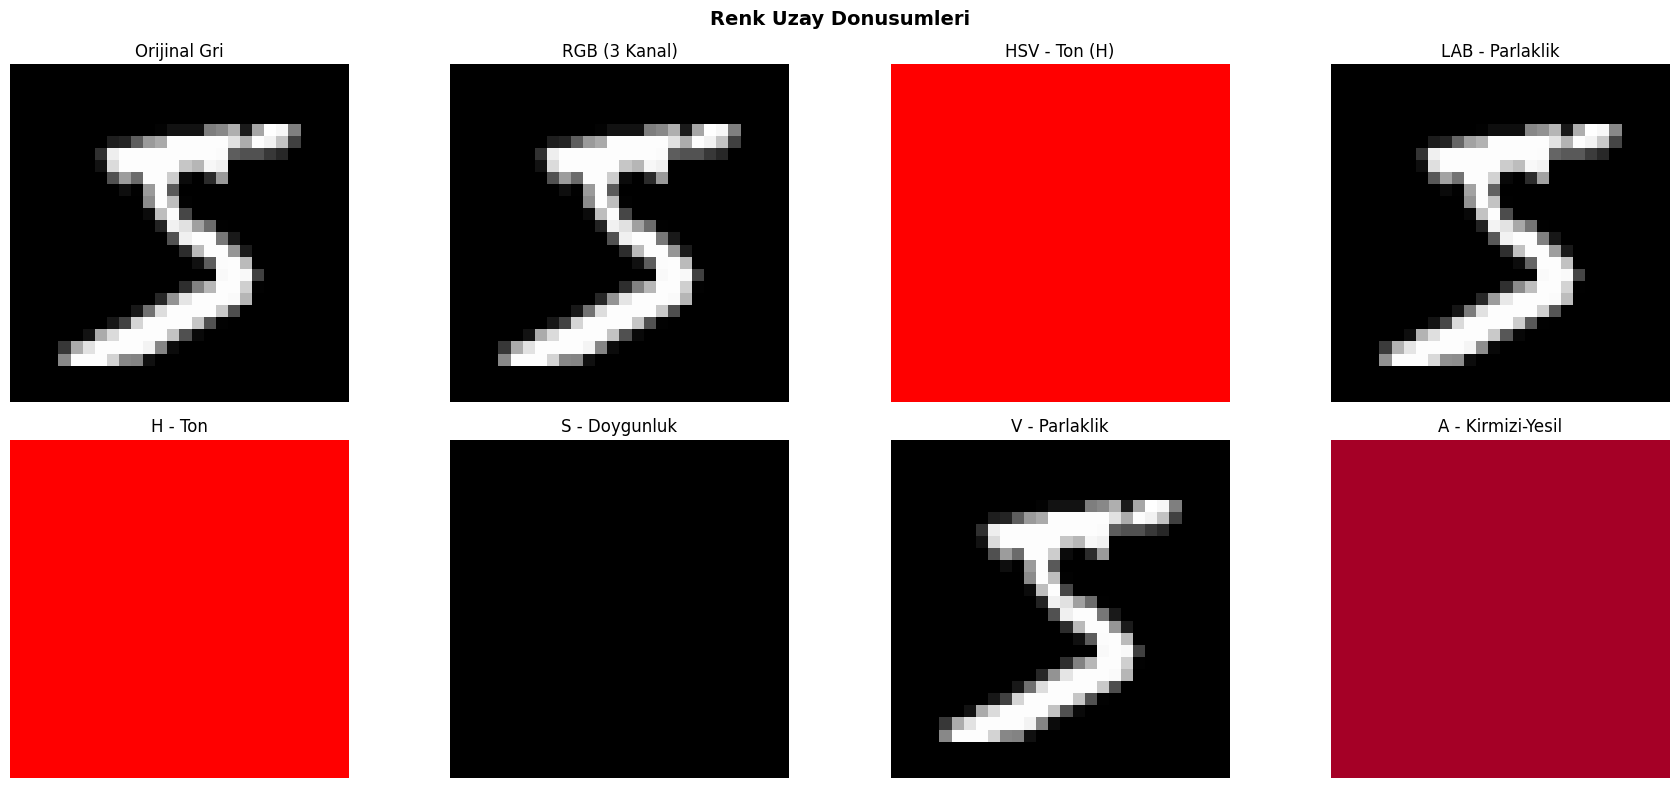

In [8]:
ornek_rgb = cv2.cvtColor(ornek, cv2.COLOR_GRAY2RGB)
hsv = cv2.cvtColor(ornek_rgb, cv2.COLOR_RGB2HSV)
lab = cv2.cvtColor(ornek_rgb, cv2.COLOR_RGB2LAB)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes[0,0].imshow(ornek, cmap='gray');      axes[0,0].set_title("Orijinal Gri")
axes[0,1].imshow(ornek_rgb);               axes[0,1].set_title("RGB (3 Kanal)")
axes[0,2].imshow(hsv[:,:,0], cmap='hsv');  axes[0,2].set_title("HSV - Ton (H)")
axes[0,3].imshow(lab[:,:,0], cmap='gray'); axes[0,3].set_title("LAB - Parlaklik")
axes[1,0].imshow(hsv[:,:,0], cmap='hsv');  axes[1,0].set_title("H - Ton")
axes[1,1].imshow(hsv[:,:,1], cmap='gray'); axes[1,1].set_title("S - Doygunluk")
axes[1,2].imshow(hsv[:,:,2], cmap='gray'); axes[1,2].set_title("V - Parlaklik")
axes[1,3].imshow(lab[:,:,1], cmap='RdYlGn'); axes[1,3].set_title("A - Kirmizi-Yesil")
for ax in axes.flat: ax.axis('off')
plt.suptitle("Renk Uzay Donusumleri", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 📊 Bolum 5 — Histogram Analizi

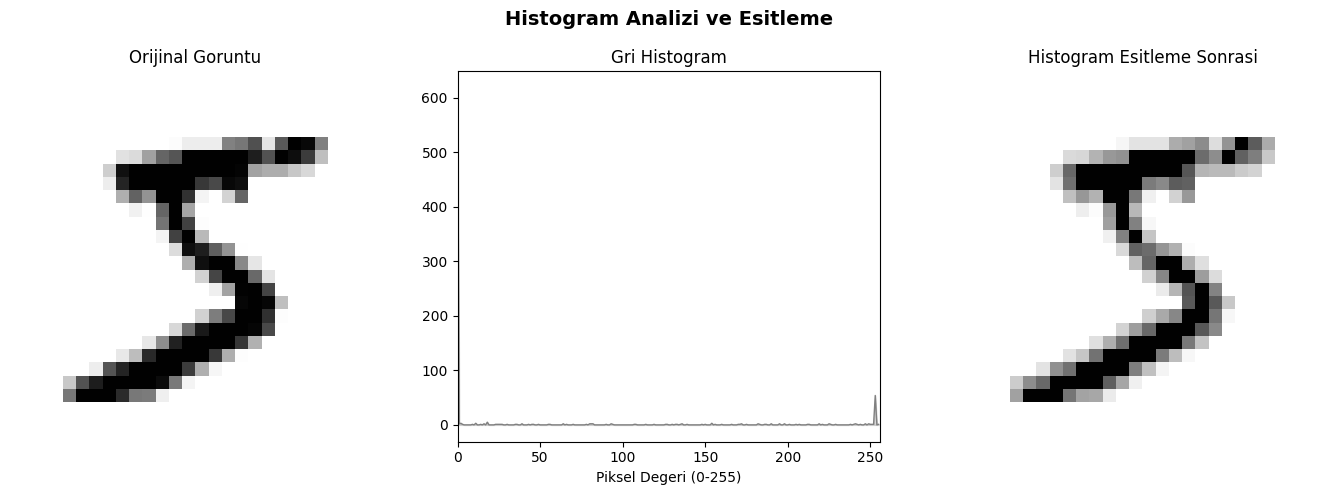

In [9]:
hist_gray, bins = np.histogram(ornek.flatten(), 256, [0, 256])
fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(1, 3, 1)
ax1.imshow(ornek, cmap='gray_r')
ax1.set_title("Orijinal Goruntu")
ax1.axis('off')

ax2 = fig.add_subplot(1, 3, 2)
ax2.plot(hist_gray, color='gray', linewidth=1)
ax2.fill_between(range(256), hist_gray, alpha=0.3, color='gray')
ax2.set_title("Gri Histogram")
ax2.set_xlabel("Piksel Degeri (0-255)")
ax2.set_xlim([0, 256])

equalized = cv2.equalizeHist(ornek)
ax3 = fig.add_subplot(1, 3, 3)
ax3.imshow(equalized, cmap='gray_r')
ax3.set_title("Histogram Esitleme Sonrasi")
ax3.axis('off')

plt.suptitle("Histogram Analizi ve Esitleme", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 🔄 Bolum 6 — Goruntu Filtreleme

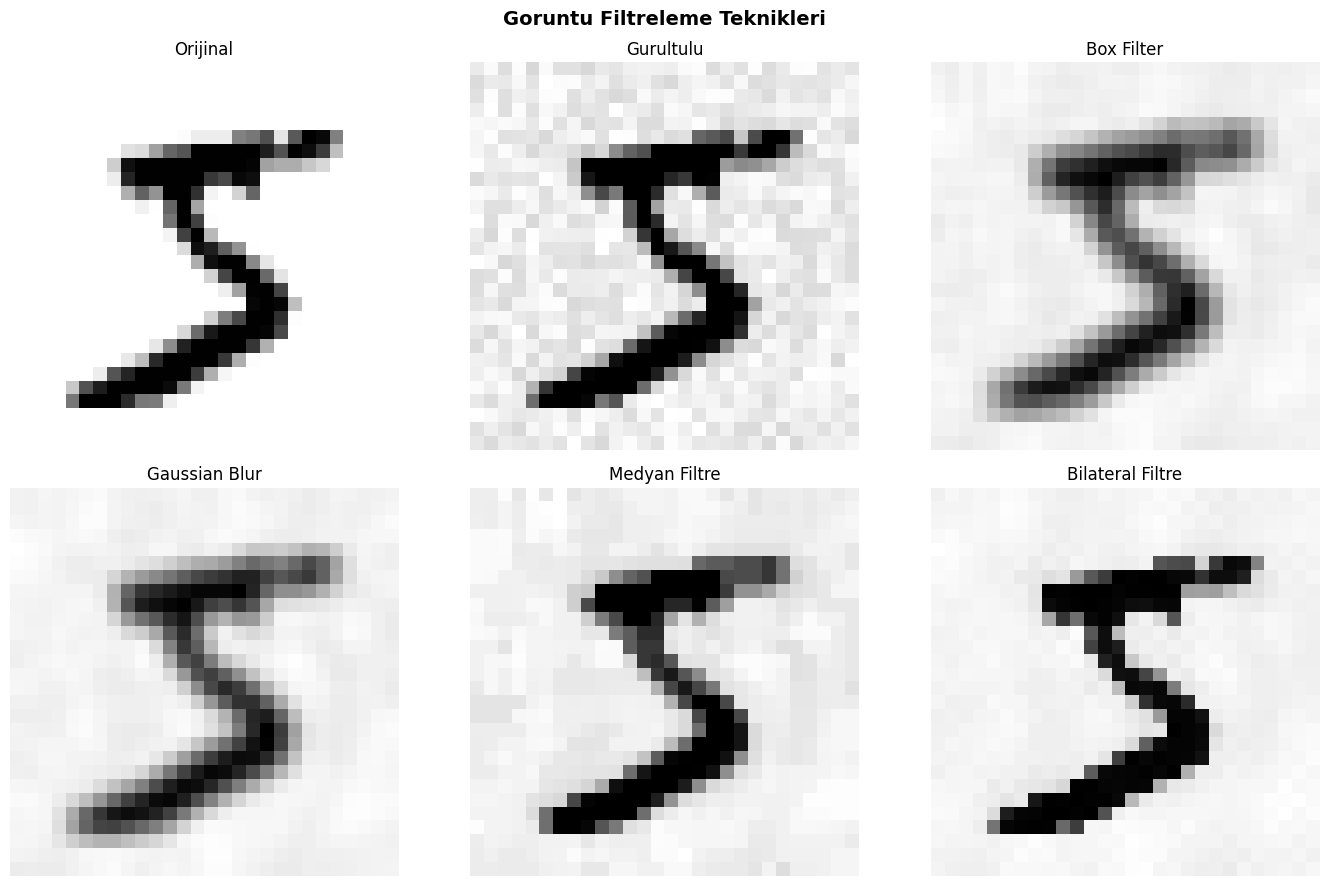

In [10]:
rng = np.random.default_rng(42)
noise = rng.integers(0, 40, ornek.shape, dtype=np.uint8)
noisy = np.clip(ornek.astype(int) + noise, 0, 255).astype(np.uint8)

kernel_box = np.ones((3, 3), np.float32) / 9
blur_box = cv2.filter2D(noisy, -1, kernel_box)
blur_gauss = cv2.GaussianBlur(noisy, (3, 3), sigmaX=1.0)
blur_median = cv2.medianBlur(noisy, 3)
kernel_sharp = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
sharp = cv2.filter2D(ornek, -1, kernel_sharp)
bilateral = cv2.bilateralFilter(noisy, d=5, sigmaColor=50, sigmaSpace=50)

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
imgs = [ornek, noisy, blur_box, blur_gauss, blur_median, bilateral]
titles = ["Orijinal", "Gurultulu", "Box Filter", "Gaussian Blur", "Medyan Filtre", "Bilateral Filtre"]
for ax, img, title in zip(axes.flat, imgs, titles):
    ax.imshow(img, cmap='gray_r'); ax.set_title(title); ax.axis('off')
plt.suptitle("Goruntu Filtreleme Teknikleri", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 🏔️ Bolum 7 — Kenar Tespiti

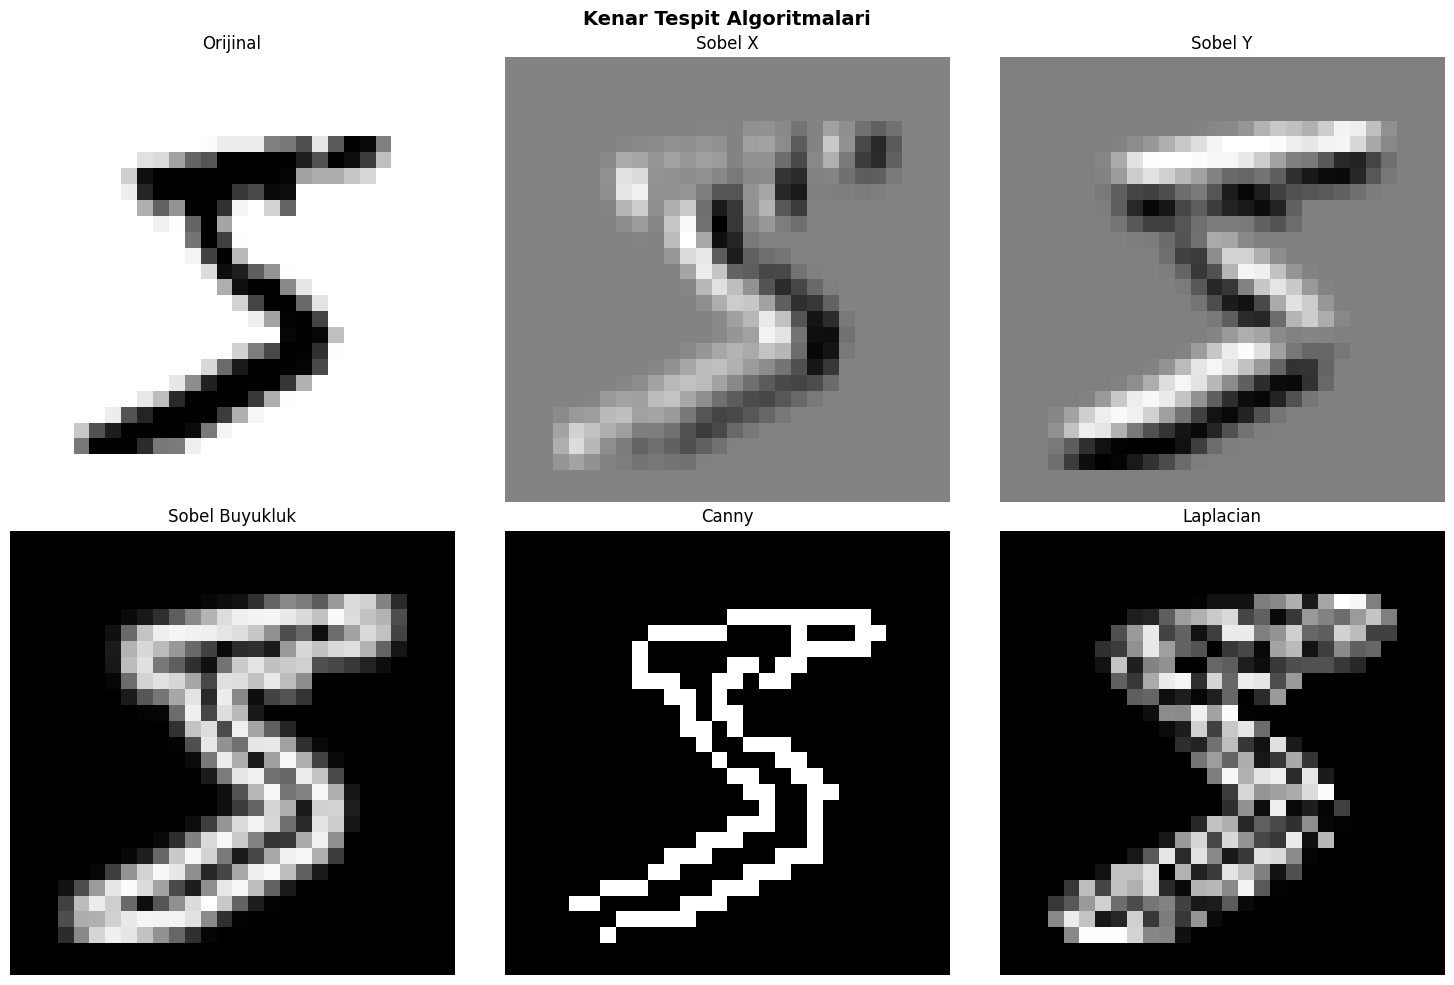

In [11]:
sobel_x = cv2.Sobel(ornek, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(ornek, cv2.CV_64F, 0, 1, ksize=3)
sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2)
edges_canny = cv2.Canny(ornek, 50, 150)
edges_laplacian = cv2.Laplacian(ornek, cv2.CV_64F)
edges_laplacian = np.uint8(np.absolute(edges_laplacian))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes[0,0].imshow(ornek, cmap='gray_r');         axes[0,0].set_title("Orijinal")
axes[0,1].imshow(sobel_x, cmap='gray');         axes[0,1].set_title("Sobel X")
axes[0,2].imshow(sobel_y, cmap='gray');         axes[0,2].set_title("Sobel Y")
axes[1,0].imshow(sobel_mag, cmap='gray');       axes[1,0].set_title("Sobel Buyukluk")
axes[1,1].imshow(edges_canny, cmap='gray');     axes[1,1].set_title("Canny")
axes[1,2].imshow(edges_laplacian, cmap='gray'); axes[1,2].set_title("Laplacian")
for ax in axes.flat: ax.axis('off')
plt.suptitle("Kenar Tespit Algoritmalari", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 🔲 Bolum 8 — Morfolojik Islemler

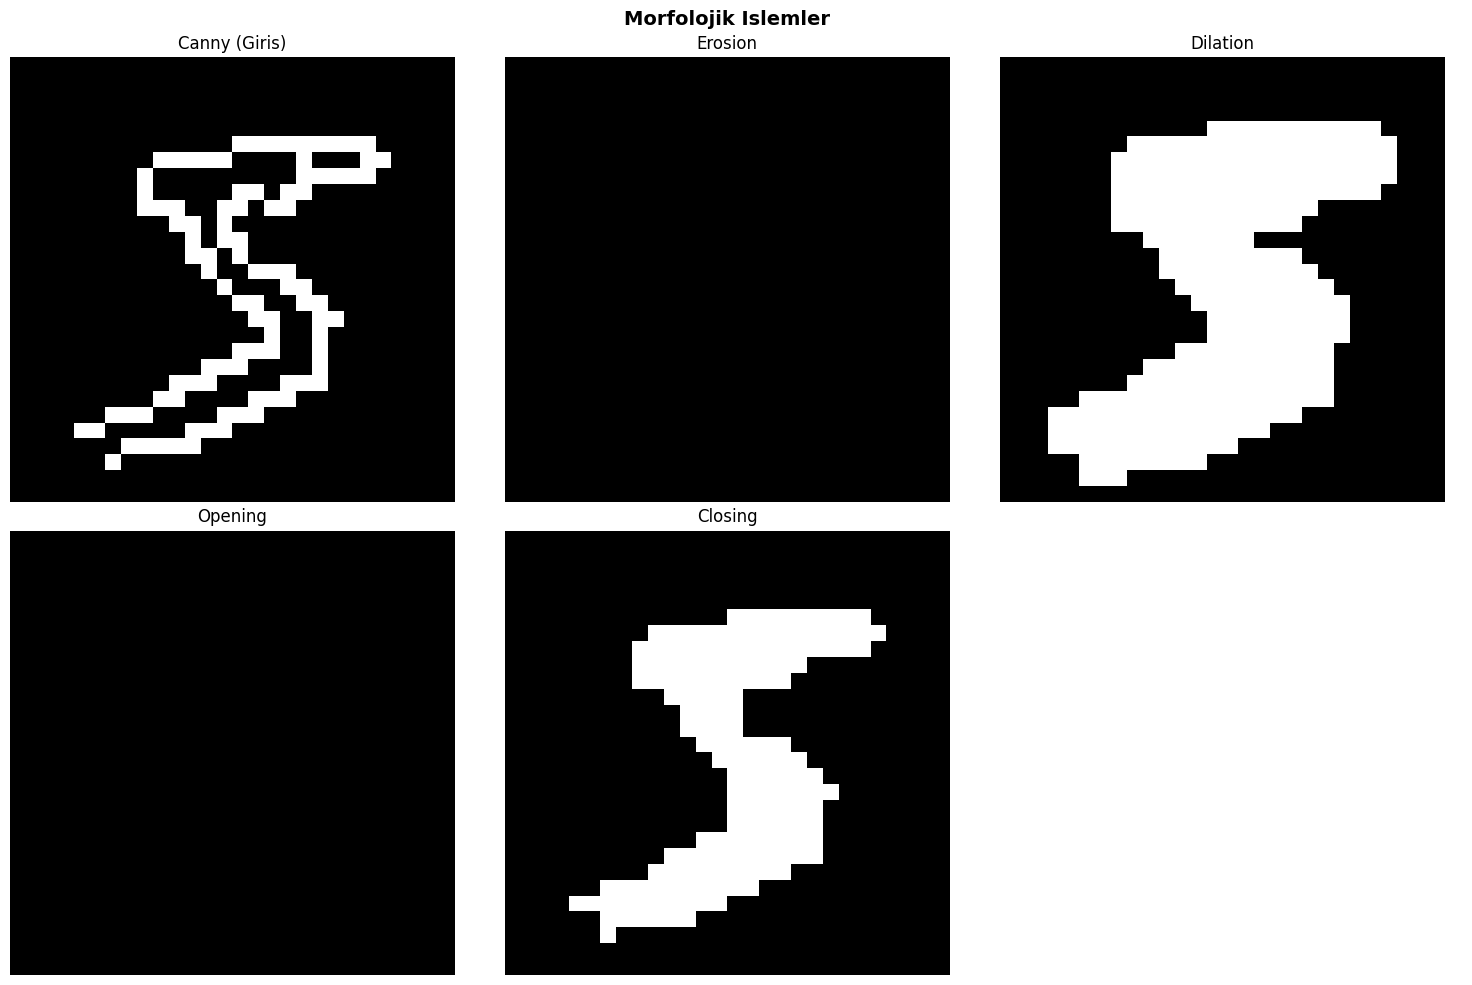

In [12]:
kernel = np.ones((3, 3), np.uint8)
erosion = cv2.erode(edges_canny, kernel, iterations=1)
dilation = cv2.dilate(edges_canny, kernel, iterations=1)
opening = cv2.morphologyEx(edges_canny, cv2.MORPH_OPEN, kernel)
closing = cv2.morphologyEx(edges_canny, cv2.MORPH_CLOSE, kernel)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes[0,0].imshow(edges_canny, cmap='gray');  axes[0,0].set_title("Canny (Giris)")
axes[0,1].imshow(erosion, cmap='gray');      axes[0,1].set_title("Erosion")
axes[0,2].imshow(dilation, cmap='gray');     axes[0,2].set_title("Dilation")
axes[1,0].imshow(opening, cmap='gray');      axes[1,0].set_title("Opening")
axes[1,1].imshow(closing, cmap='gray');      axes[1,1].set_title("Closing")
axes[1,2].axis('off')
for ax in axes.flat: ax.axis('off')
plt.suptitle("Morfolojik Islemler", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## ⬜ Bolum 9 — Esikleme (Thresholding)

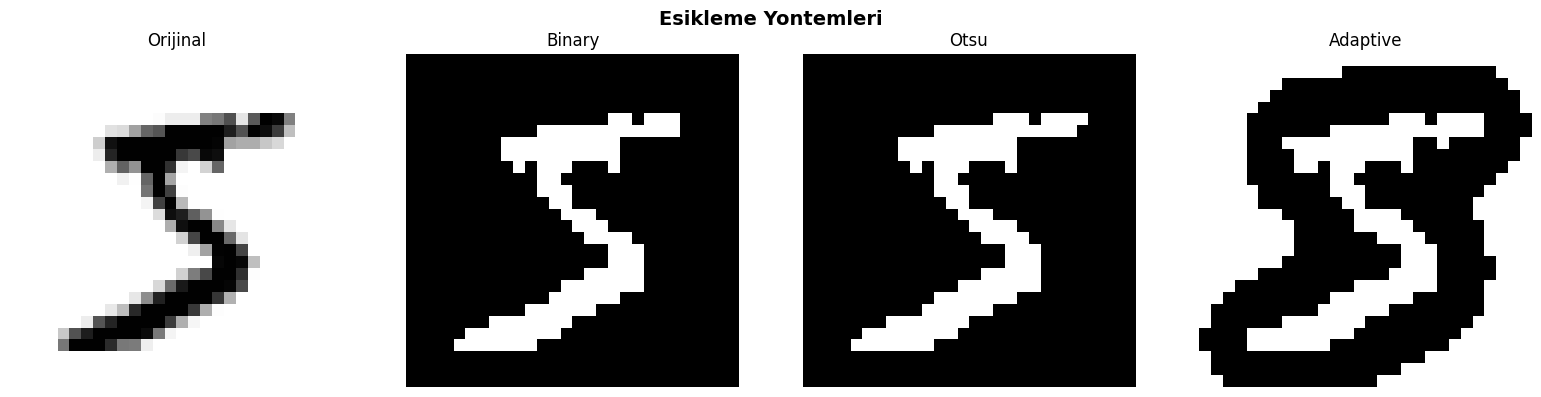

In [13]:
_, binary = cv2.threshold(ornek, 127, 255, cv2.THRESH_BINARY)
_, otsu = cv2.threshold(ornek, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
adaptive = cv2.adaptiveThreshold(ornek, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(ornek, cmap='gray_r');    axes[0].set_title("Orijinal")
axes[1].imshow(binary, cmap='gray');     axes[1].set_title("Binary")
axes[2].imshow(otsu, cmap='gray');       axes[2].set_title("Otsu")
axes[3].imshow(adaptive, cmap='gray');   axes[3].set_title("Adaptive")
for ax in axes.flat: ax.axis('off')
plt.suptitle("Esikleme Yontemleri", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 🔍 Bolum 10 — Kontur Tespiti

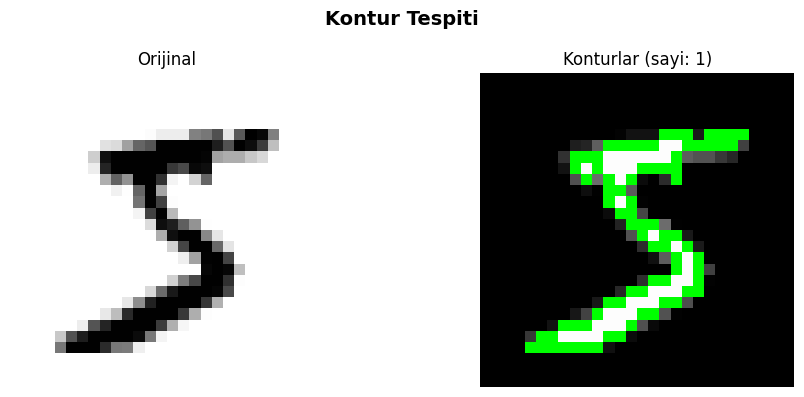

Tespit edilen kontur sayisi: 1


In [14]:
konturlar, _ = cv2.findContours(otsu, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
goruntu_kontur = cv2.cvtColor(ornek, cv2.COLOR_GRAY2RGB)
cv2.drawContours(goruntu_kontur, konturlar, -1, (0, 255, 0), 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.imshow(ornek, cmap='gray_r'); ax1.set_title("Orijinal"); ax1.axis('off')
ax2.imshow(goruntu_kontur); ax2.set_title(f"Konturlar (sayi: {len(konturlar)})"); ax2.axis('off')
plt.suptitle("Kontur Tespiti", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"Tespit edilen kontur sayisi: {len(konturlar)}")

## 🤖 Bolum 11 — Ozellik Cikarimi ve Siniflandirma (KNN)

In [ ]:
X_flat = X_images.reshape(len(X_images), -1)
X_train, X_test, y_train, y_test = train_test_split(X_flat, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_sc, y_train)
y_pred = knn.predict(X_test_sc)
accuracy = np.mean(y_pred == y_test)

print(f"KNN Dogruluk: {accuracy*100:.2f}%")
print("\nSiniflandirma Raporu:")
print(classification_report(y_test, y_pred))

In [ ]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.set_title("Karisiklik Matrisi")
plt.colorbar(im, ax=ax)
tick_marks = np.arange(10)
ax.set_xticks(tick_marks); ax.set_xticklabels(tick_marks)
ax.set_yticks(tick_marks); ax.set_yticklabels(tick_marks)
ax.set_ylabel("Gercek Etiket")
ax.set_xlabel("Tahmin Edilen")
plt.tight_layout()
plt.show()

---
## 📝 Ozet

Bu notebook'ta ogrenilenler:
1. Piksel, kanal, boyut kavramlari
2. Kirpma, dondurme, cevirme manipulasyonlari
3. Gri tonlama ve renk uzaylari
4. Histogram analizi ve esitleme
5. Goruntu filtreleme (Box, Gaussian, Medyan, Bilateral)
6. Kenar tespiti (Sobel, Canny, Laplacian)
7. Morfolojik islemler
8. Esikleme (Binary, Otsu, Adaptive)
9. Kontur tespiti
10. KNN ile siniflandirma